<a href="https://colab.research.google.com/github/Hongleili/KV7006/blob/main/Week_8_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part I Pipeline of Convolutional Neural Network**

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


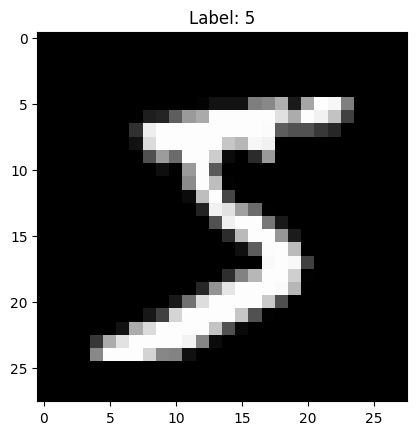

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Load and preprocess the MNIST dataset - it is already included in tensorflow.

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# How many cases? What is the image size?
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

#Let us display one sample image, using the first image [0] and the first label here.

plt.figure()
plt.imshow(train_images[0], cmap='gray')   # it is a gray scale image - not binary. Each pixel value is in [0-255].
plt.title(f"Label: {(train_labels[0])}")
plt.show()


Let us select a small portion of each category randomly - try to do a faster experiment. However, please explore the whole dataset. Consider accelerating with GPU - see how much faster.

In [ ]:
train_images_small = []
train_labels_small = []
test_images_small = []
test_labels_small = []

smallpct = 0.25;

for i in range(10):
    indices = np.where(train_labels == i)[0]
    np.random.shuffle(indices)
    selected_indices = indices[:int(smallpct * len(indices))]
    train_images_small.extend(train_images[selected_indices])
    train_labels_small.extend(train_labels[selected_indices])

    indices = np.where(test_labels == i)[0]
    np.random.shuffle(indices)
    selected_indices = indices[:int(smallpct * len(indices))]
    test_images_small.extend(test_images[selected_indices])
    test_labels_small.extend(test_labels[selected_indices])


Check the number of training samples

In [ ]:
len(train_labels_small)

14995

Let us reformat data into array and map the pixel value from [0 - 255] to [0 - 1].

In [ ]:
train_images_small = np.array(train_images_small).astype('float32') / 255
test_images_small = np.array(test_images_small).astype('float32') / 255

# Corrected one-hot encoding of the labels
# Ensure labels are treated as integers before one-hot encoding
y_train_temp = np.array(train_labels_small)
y_test_temp = np.array(test_labels_small)

train_labels_small = to_categorical(y_train_temp)
test_labels_small = to_categorical(y_test_temp)

Notice the shape of output label. Initially was a value [0-9] but it has now been one-hot encoded.

In [ ]:
print(train_images_small.shape)
print(train_labels_small.shape)
print(test_images_small.shape)
print(test_labels_small.shape)


(14995, 28, 28)
(14995, 10, 2)
(2497, 28, 28)
(2497, 10, 2)


Let us build a CNN model.

In [ ]:
 m tensorflow.keras import Input

model = models.Sequential([
    Input(shape=(28, 28, 1)), # Explicit Input layer
    layers.Conv2D(16, (3, 3), activation='relu'),    # 16 filters, each size is (3,3)
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(9, (3, 3), activation='relu'), # 8 filters, each size is (3,3)
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),    # 64 hidden unit. Can be more or be less.
    layers.Dense(10, activation='softmax')  # must be 10, as there are 10 different outputs.
])

We can see the summary of the model using the following code:

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 9)      │         1,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 9)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 225)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,579 (64.76 KB)

 Trainable params: 16,579 (64.76 KB)

 Non-trainable params: 0 (0.00 B)

Let us compile the CNN model.

In [ ]:
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## Training the Model

Training the model involves feeding it the training data (`train_images_small` and `train_labels_small`) and allowing it to learn the patterns. During this process, the model adjusts its internal weights to minimize the loss function and improve its accuracy. We'll specify the number of training epochs (how many times the model sees the entire training dataset) and the batch size (number of samples per gradient update).

In [ ]:
history = model.fit(train_images_small,
                    train_labels_small,
                    epochs=15, # Number of times to iterate over the entire training dataset
                    batch_size=64, # Number of samples per gradient update
                    validation_data=(test_images_small, test_labels_small)
                   )

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.2592 - loss: 2.1176 - val_accuracy: 0.5599 - val_loss: 1.5659
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7653 - loss: 0.8455 - val_accuracy: 0.8366 - val_loss: 0.5302
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8629 - loss: 0.4587 - val_accuracy: 0.8746 - val_loss: 0.4054
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8882 - loss: 0.3656 - val_accuracy: 0.8851 - val_loss: 0.3874
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9067 - loss: 0.3115 - val_accuracy: 0.9275 - val_loss: 0.2655
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9165 - loss: 0.2743 - val_accuracy: 0.9163 - val_loss: 0.2840
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9236 - loss: 0.2501 - val_accuracy: 0.9399 - val_loss: 0.2218
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9290 - loss: 0.2253 - val_acc

### Explanation of Training Parameters:

*   **`epochs`**: One epoch means that the training algorithm has completed one full pass through the entire training dataset. More epochs can lead to a better-trained model, but also risk overfitting.
*   **`batch_size`**: This defines the number of samples that will be propagated through the network at once. A larger batch size usually results in faster training but requires more memory.
*   **`validation_split`**: A portion of the training data will be set aside and used to evaluate the model's performance during training. This helps monitor for overfitting and provides an estimate of how well the model generalizes to unseen data.

Print training history

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


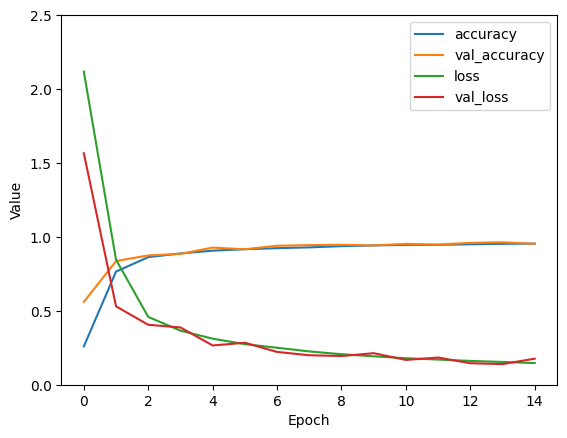

In [ ]:
print(history.history.keys())
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.ylim([0, 2.5])
plt.legend(loc='upper right')
plt.show()



**Part 2	Development  of CNN for Nature Conservancy Fisheries Monitoring**

**Part 2 Development of CNN for Nature Conservancy Fisheries Monitoring**

Part 2 is about the Nature Conservancy Fisheries Monitoring dataset. "Nearly half of the world depends on seafood for their main source of protein. In the Western and Central Pacific, where 60% of the world’s tuna is caught, illegal, unreported, and unregulated fishing practices are threatening marine ecosystems, global seafood supplies and local livelihoods. The Nature Conservancy is working with local, regional and global partners to preserve this fishery for the future. Currently, the Conservancy is looking to the future by using cameras to dramatically scale the monitoring of fishing activities to fill critical science and compliance monitoring data gaps. Although these electronic monitoring systems work well and are ready for wider deployment, the amount of raw data produced is cumbersome and expensive to process manually." "The objective is to develop algorithms to automatically detect and classify species of tunas, sharks and more that fishing boats catch, which will accelerate the video review process. Faster review and more reliable data will enable countries to reallocate human capital to management and enforcement activities which will have a positive impact on conservation and our planet."

### Loading the Fisheries Monitoring Dataset

TThe first stage is to load and prepare the data from the zip file you can download from blackboard. Once you have downloaded the zip file, upload it to your personal Google Drive - this is good practice when using Colab as we can access the data directly, without having to upload the file again each time we open the notebook. Once the file is in your Google Drive, you are required to extract it the images and labels from the subdirectories. Each subdirectory represents a label for fish type. That means we must create a list of all the subdirectories first. Then load the images from each of these subdirectories. Finally, print out the dimensions to see how your data looks like.



Mount the Google Drive to allow you to access your files


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Unzip the data file - this will save the all.small directory to your working directory (Google Colab content folder)

In [ ]:
from zipfile import ZipFile
zip_file = '/content/drive/MyDrive/all.small.zip'
with ZipFile(zip_file, 'r') as zip:
  zip.extractall()


Loop through the subdirectories in the "all.small" folder

In [ ]:
import os
directories = [d for d in os.listdir("all.small")]
directories



['BET', 'SHARK', 'NoF', 'ALB', 'LAG', 'OTHER', 'YFT', 'DOL']

Let us see an example.

File exists!


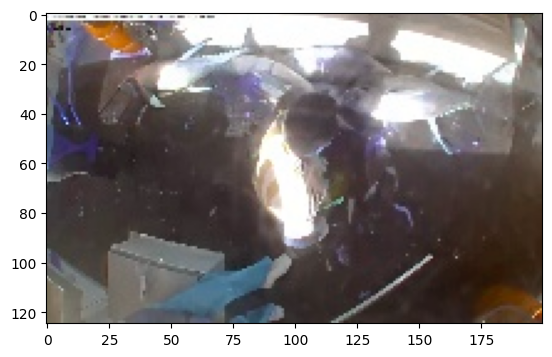

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Showing an image

file_name = "all.small/YFT/img_07911.jpg";

if os.path.exists(file_name):
    print("File exists!")
else:
    print("File does not exist.")

try_image = cv2.imread(file_name)

plt.figure()
plt.imshow(try_image)
plt.show()


In [ ]:
import cv2 # computer vision package we've used before
import numpy as np

# Loop through the label subdirectories and collect the data in two lists,
# one list for labels themselves and one list for the images inside those label folders.
labels = []
images = []
category = 0 # this is temp label the data based on the subdirectory name

for d in directories:
    label_dir = os.path.join("all.small", d)
    # get all the image files (all .jpg) in each subdirectory
    file_names = [os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".jpg")]

    counter = 0 # I put this counter in order to work on a part of the images coz it takes a while
    for f in file_names:
      #print(f)
      img = cv2.imread(f)
      imresize = cv2.resize(img, (100, 60))     # the original size is (200, 125). it is optional to reduce.
      images.append(imresize)
      labels.append(category)
      if counter > 50:  # remove this to use full dataset. Guess, how many will be given this counter? Really 50?
        break
      counter += 1

    print('Number of images in this cat', counter)   # I guess you are seeing 51, are there 51 images?

    category += 1 # we increment when finishing the subdirectory before moving to another subdirectory for another fish type
    print(category)




Number of images in this cat 51
1
Number of images in this cat 51
2
Number of images in this cat 51
3
Number of images in this cat 51
4
Number of images in this cat 51
5
Number of images in this cat 51
6
Number of images in this cat 51
7
Number of images in this cat 51
8


In [ ]:
images = np.array(images)
print(images.shape)


(416, 60, 100, 3)


In [ ]:
labels = np.array(labels)
print(labels.shape)
print(labels)


(416,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7]


You are required to split the data into train and test sets where the test set is 20%

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=1234)


Let us check out the dimensions of the training and test dataset.

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(332, 60, 100, 3)
(332,)
(84, 60, 100, 3)
(84,)


You are required to normalize the image data to be between [0,1]. Also, you need to prepare the labels where we have multiple labels this time. So, definitely, we need one-hot encoding.

In [ ]:
from tensorflow.keras.utils import to_categorical

# normalize inputs from [0.0, 255.0] to end up with input in the range [0.0, 1.0]
X_train = np.array(X_train).astype('float32')
X_test = np.array(X_test).astype('float32')
X_train /= 255.0
X_test /= 255.0

# one-hot encoding of the labels
y_train = np.array(y_train)
y_test = np.array(y_test)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [ ]:
print(y_train.shape) # this is the shape after one-hot encoding

(332, 8)


In [ ]:
num_classes = y_train.shape[1]
print(num_classes)


8


Now, it's your turn to build the CNN model.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, MaxPooling2D, Flatten

# Create the model
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(60, 100, 3), activation='relu'))      # 125, 200, 3
# model.add(Dropout(0.2))   # it is ootional we use dropout
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.5))   # it is ootional we use dropout
model.add(Dense(num_classes, activation='softmax')) # num_classes = 8

# Compile model
epochs = 25   # should be 25+
lr = 0.01     # learning rate
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 58, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 43008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    22,020,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,034,856 (84.06 MB)

 Trainable params: 22,034,856 (84.06 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 58, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 43008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    22,020,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,034,856 (84.06 MB)

 Trainable params: 22,034,856 (84.06 MB)

 Non-trainable params: 0 (0.00 B)

Now, you are required to train and validate the model. Use Early_stopping to control the epochs.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(monitor='loss', patience=3)    # it function is looking at the loss, if it doesn't change for 3 epoches. then stop....before reaching 25.

seed = 1234
np.random.seed(seed)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=64, callbacks=[callback])

print(len(history.history['loss']))


Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1265 - loss: 2.0840 - val_accuracy: 0.1071 - val_loss: 2.0794
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 875ms/step - accuracy: 0.2349 - loss: 2.0228 - val_accuracy: 0.1429 - val_loss: 2.0216
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2530 - loss: 1.9825 - val_accuracy: 0.1071 - val_loss: 2.0214
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 846ms/step - accuracy: 0.3193 - loss: 1.9210 - val_accuracy: 0.1667 - val_loss: 1.9841
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3223 - loss: 1.8686 - val_accuracy: 0.2024 - val_loss: 2.1403
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 973ms/step - accuracy: 0.3373 - loss: 1.8399 - val_accuracy: 0.2976 - val_loss: 1.8516
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 980ms/step - accuracy: 0.4006 - loss: 1.7231 - val_accuracy: 0.4048 - val_loss: 1.7355
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3825 - loss: 1.7081 - val_accuracy: 0.2857 - val_loss: 2.1108


In [ ]:
import matplotlib.pyplot as plt
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()


TASKS
1.	Discuss the architecture of this CNN model in terms of number of layers, the size of kernel, number of feature maps.
2.	Develop a new CNN model that performs with better accuracy than the one you have just implemented.


## 2. Develop a new CNN model with improved accuracy

To improve accuracy, we'll build a new CNN model (`model_improved`) with a deeper architecture and regularization:

*   **More Convolutional Layers**: Adding more `Conv2D` layers allows the model to learn more complex features.
*   **Increased Filters**: Gradually increasing the number of filters (e.g., 32 -> 64 -> 128) in deeper layers helps capture more intricate patterns.
*   **Dropout Layer**: A `Dropout` layer randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting, especially in models with many parameters.
*   **Adam Optimizer**: Often provides faster convergence and better performance compared to SGD in many deep learning tasks.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, MaxPooling2D, Flatten, Input

# Create the improved model
model_improved = Sequential([
    Input(shape=(60, 100, 3)), # Explicit Input layer for 60x100 RGB images
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(num_classes, activation='softmax') # num_classes should be 8
])

# Compile the improved model with Adam optimizer
model_improved.compile(optimizer='adam', # Using Adam optimizer
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print(model_improved.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 58, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 29, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 27, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 10, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,664 (12.87 MB)

 Trainable params: 3,374,664 (12.87 MB)

 Non-trainable params: 0 (0.00 B)

None


### Training the Improved Model

Now, let's train this new model using the same training and validation data. We'll use EarlyStopping to ensure we don't overtrain.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Use a callback for early stopping based on validation loss
callback_improved = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Set epochs and batch size
epochs_improved = 50 # Increased epochs, but early stopping will control it
batch_size_improved = 32 # Adjusted batch size

# Train the improved model
history_improved = model_improved.fit(X_train, y_train,
                                      validation_data=(X_test, y_test),
                                      epochs=epochs_improved,
                                      batch_size=batch_size_improved,
                                      callbacks=[callback_improved])


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - accuracy: 0.1958 - loss: 2.0755 - val_accuracy: 0.1786 - val_loss: 2.0561
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 293ms/step - accuracy: 0.2349 - loss: 1.9753 - val_accuracy: 0.3690 - val_loss: 1.8611
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - accuracy: 0.3524 - loss: 1.7965 - val_accuracy: 0.2262 - val_loss: 1.8918
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 478ms/step - accuracy: 0.4127 - loss: 1.5936 - val_accuracy: 0.5119 - val_loss: 1.4850
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.5030 - loss: 1.3914 - val_accuracy: 0.4881 - val_loss: 1.5006
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 456ms/step - accuracy: 0.5422 - loss: 1.3106 - val_accuracy: 0.5476 - val_loss: 1.3457
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.6777 - loss: 0.9755 - val_accuracy: 0.6310 - val_loss: 1.2228
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - accuracy: 0.7078 - loss: 0.8277 - val_accuracy: 0.

### Plotting Training History for the Improved Model

Let's visualize the training and validation accuracy and loss for our improved model to assess its performance.

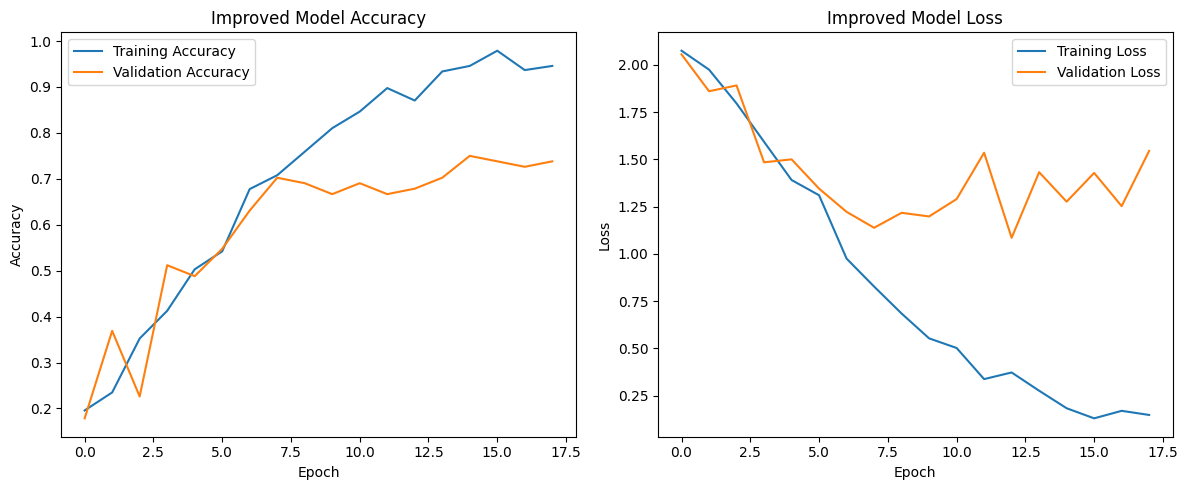

In [ ]:
import matplotlib.pyplot as plt

# Plotting accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Improved Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Improved Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Discussion of the CNN Model Architecture

Based on the `model.summary()` output, here's a detailed discussion of your CNN model's architecture:

**1. Input Layer**
*   **Implicit Input Shape**: The model implicitly takes an input of shape `(60, 100, 3)`, representing images of 60 pixels height, 100 pixels width, and 3 color channels (RGB). This aligns with the `imresize = cv2.resize(img, (100, 60))` operation where images are resized to 100 width and 60 height, and they are color images.

**2. Convolutional Layers (`Conv2D`)**
*   **First `Conv2D` Layer (`conv2d_6`)**:
    *   **Number of Filters (Feature Maps)**: 32
    *   **Kernel Size**: `(3, 3)` (a 3x3 filter)
    *   **Activation Function**: ReLU (Rectified Linear Unit), which introduces non-linearity.
    *   **Output Shape**: `(None, 58, 98, 32)`. The spatial dimensions (height and width) reduce from (60, 100) to (58, 98) due to convolution with default 'valid' padding. The depth of the output increases to 32, representing 32 different feature maps learned by this layer.
*   **Second `Conv2D` Layer (`conv2d_7`)**:
    *   **Number of Filters (Feature Maps)**: 32
    *   **Kernel Size**: `(3, 3)`
    *   **Activation Function**: ReLU
    *   **Output Shape**: `(None, 56, 96, 32)`. Another convolutional operation further reduces the spatial dimensions (from (58, 98) to (56, 96)), while maintaining 32 feature maps. This layer extracts higher-level features from the outputs of the previous convolutional layer.

**3. Pooling Layer (`MaxPooling2D`)**
*   **`MaxPooling2D` Layer (`max_pooling2d_6`)**:
    *   **Pool Size**: `(2, 2)` (takes the maximum value over a 2x2 window)
    *   **Output Shape**: `(None, 28, 48, 32)`. This layer significantly reduces the spatial dimensions (56/2 = 28, 96/2 = 48) by picking the most prominent feature within each 2x2 window. Max pooling helps in reducing computation, controlling overfitting, and making the model more robust to small translations of the input features.

**4. Flatten Layer (`Flatten`)**
*   **`Flatten` Layer (`flatten_3`)**:
    *   **Purpose**: This layer converts the 3D output of the last pooling layer (`(28, 48, 32)`) into a 1D vector. This transformation is crucial because the subsequent dense (fully connected) layers expect a 1D input.
    *   **Output Shape**: `(None, 43008)`. The total number of elements `28 * 48 * 32` is flattened into a single vector of length 43008.

**5. Dense (Fully Connected) Layers**
*   **First `Dense` Layer (`dense_6`)**:
    *   **Number of Neurons**: 512
    *   **Activation Function**: ReLU
    *   **Output Shape**: `(None, 512)`. This is a traditional neural network layer that learns complex non-linear combinations from the flattened feature vector. It has a very large number of parameters due to being fully connected to the extensive flattened input.
*   **Output `Dense` Layer (`dense_7`)**:
    *   **Number of Neurons**: 8 (This corresponds to `num_classes`, which is the number of distinct fish types in your dataset).
    *   **Activation Function**: Softmax. The softmax function converts the raw output scores from the 8 neurons into a probability distribution, where each value indicates the probability of the input image belonging to that specific fish class. The sum of these probabilities for each input image will be 1.
    *   **Output Shape**: `(None, 8)`.

**Summary of Parameters:**
*   **Total parameters**: 22,034,856
*   **Trainable parameters**: 22,034,856 (All parameters in this model are learned during the training process.)
*   **Non-trainable parameters**: 0

**Overall Architecture Discussion:**
This CNN architecture follows a common and effective pattern for image classification: a stack of convolutional and pooling layers for automatic feature extraction, followed by dense layers for classification. The convolutional layers progressively extract more abstract features from the images, and the pooling layers reduce the dimensionality and computational load. The flatten layer bridges the gap between these feature extractors and the final classification layers. The significant number of parameters, particularly in the first dense layer, indicates the model's capacity to learn complex patterns. Given the relatively small dataset size (51 images per category), careful monitoring for overfitting is important, although the use of `EarlyStopping` helps mitigate this by preventing training for too long.